In [17]:
import json
import os

import pandas as pd

from scripts.plotting import make_barplot_double

dir = '../data/results/experiments/beam_matching_experiment_12'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['errors'] = data_df['errors'].apply(json.loads)
data_df['complexity'] = data_df['complexity'].apply(json.loads)

data_df

,config,use_best_beam,use_sidelobes,n_best_pcis,errors,complexity,errors_control,complexity_control
0,baseline,False,False,1,"[6.451838366956337, 6.305423890629361, 6.06680...","[105044.38167330678, 105057.03640588692, 10535...","[3.9419786272902084, 3.9018033350741614, 3.936...","[1497584.0, 1480058.0, 1492250.0, 1509522.0, 1..."
1,best_beam,True,False,1,"[43.45404871502246, 43.89055270691789, 43.9985...","[413.5605577689243, 413.61037955073584, 414.77...","[3.9419786272902084, 3.9018033350741614, 3.936...","[1497584.0, 1480058.0, 1492250.0, 1509522.0, 1..."
2,best_beam_with_sidelobes,True,True,1,"[32.395980900705055, 33.14492586139382, 33.091...","[1240.6816733067728, 1240.8311386522075, 1244....","[3.9419786272902084, 3.9018033350741614, 3.936...","[1497584.0, 1480058.0, 1492250.0, 1509522.0, 1..."


In [18]:
import numpy as np

baseline = data_df[data_df['use_best_beam'] == False].iloc[0]

baseline_error = np.array(baseline['errors']).mean()
baseline_complexity = np.array(baseline['complexity']).mean()

print(f'baseline_error {baseline_error}, baseline_complexity {baseline_complexity}')

baseline_error 6.298757157599641, baseline_complexity 105308.33683381035


In [19]:
errors_df = data_df[data_df['use_best_beam'] == True][['use_sidelobes', 'n_best_pcis', 'errors']]
errors_df.sort_values('n_best_pcis', ascending=True, inplace=True)

data = {}
data_control = {}
for _, row in errors_df.iterrows():
    if row["use_sidelobes"]:
        data_control[row["n_best_pcis"]] = row["errors"]
    else:
        data[row["n_best_pcis"]] = row["errors"]

errors_df = pd.DataFrame(data)
errors_df_control = pd.DataFrame(data_control)

complexity_df = data_df[data_df['use_best_beam'] == True][['use_sidelobes', 'n_best_pcis', 'complexity']]
complexity_df.sort_values('n_best_pcis', ascending=True, inplace=True)

data = {}
data_control = {}
for _, row in complexity_df.iterrows():
    if row["use_sidelobes"]:
        data_control[row["n_best_pcis"]] = row["complexity"]
    else:
        data[row["n_best_pcis"]] = row["complexity"]

complexity_df = pd.DataFrame(data)
complexity_df_control = pd.DataFrame(data_control)

In [20]:
from typing import Union
import matplotlib.pyplot as plt


def make_boxplot_double(
        df: pd.DataFrame,
        control_df: pd.DataFrame,
        title: str,
        x_label: str,
        y_label: str,
        legend_labels: list[str],
        color: Union[str, dict] = "forestgreen",
        baseline: float = None,
        annotate: bool = False,
):
    """
    Creates a boxplot of the given dataframes.

    :param legend_labels:
    :param control_df: DataFrame containing control data
    :param baseline: Optional baseline value to plot
    :param df: DataFrame containing experimental data
    :param title: Plot title
    :param x_label: X-axis label
    :param y_label: Y-axis label
    :param color: Color of the boxes (str or dict mapping column names to colors)
    :param annotate: Whether to annotate mean values
    """
    # Prepare data by pairing control and regular columns
    data_values = []
    labels = []
    means = []
    positions = []

    # Calculate positions for paired boxes
    for i in range(len(df.columns)):
        base_pos = i * 3  # Leave more space between pairs
        positions.extend([base_pos, base_pos + 1])  # Positions for control and regular

        col_name = df.columns[i]

        # Add control column
        data_values.append(control_df[col_name])
        labels.append(col_name)  # Use actual column name instead of number
        means.append(control_df[col_name].mean())

        # Add regular column
        data_values.append(df[col_name])
        labels.append(col_name)  # Use actual column name for the pair
        means.append(df[col_name].mean())

    num_boxes = len(data_values)

    plt.figure(figsize=(20, 12))
    median_props = dict(color="black", linewidth="3")
    plot = plt.boxplot(
        data_values,
        positions=positions,  # Use custom positions
        patch_artist=True,
        medianprops=median_props,
    )

    # Handle color and hatch assignment
    legend_elements = []
    for i, patch in enumerate(plot["boxes"]):
        current_col = labels[i]
        current_color = color[current_col] if isinstance(color, dict) else color

        if i % 2 == 0:  # Control boxes
            patch.set_facecolor('red')
            patch.set_hatch("x")
            legend_elements.append(patch)
        else:  # Regular boxes
            patch.set_facecolor(current_color)
            patch.set_hatch("\\")
            legend_elements.append(patch)

    baseline_line = None
    if baseline:
        baseline_line = plt.axhline(
            y=baseline,
            color="red",
            linestyle="-",
            linewidth=2,
            label="Baseline",
        )

    if annotate:
        text_offset = 0.22 if num_boxes < 4 else 0.4
        for i, mean in enumerate(means):
            plt.text(
                positions[i] + text_offset,
                mean,
                f"\n{mean:.2f}",
                horizontalalignment="right",
                verticalalignment="center",
                color="black",
            )

    # Add legend
    # Add legend with baseline if it exists
    if baseline_line:
        plt.legend(
            legend_elements[:2] + [baseline_line],
            legend_labels[:2] + ["Baseline"],
            loc="upper right"
        )
    else:
        plt.legend(legend_elements, legend_labels[:2], loc="upper right")

    # formatting the plot
    plt.title(title)
    plt.grid(axis="y")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.margins(x=0.1)

    # Set x-ticks at the center of each pair
    tick_positions = [pos + 0.5 for pos in positions[::2]]  # Center between each pair
    plt.xticks(tick_positions, df.columns)

    # Show the plot
    plt.show()


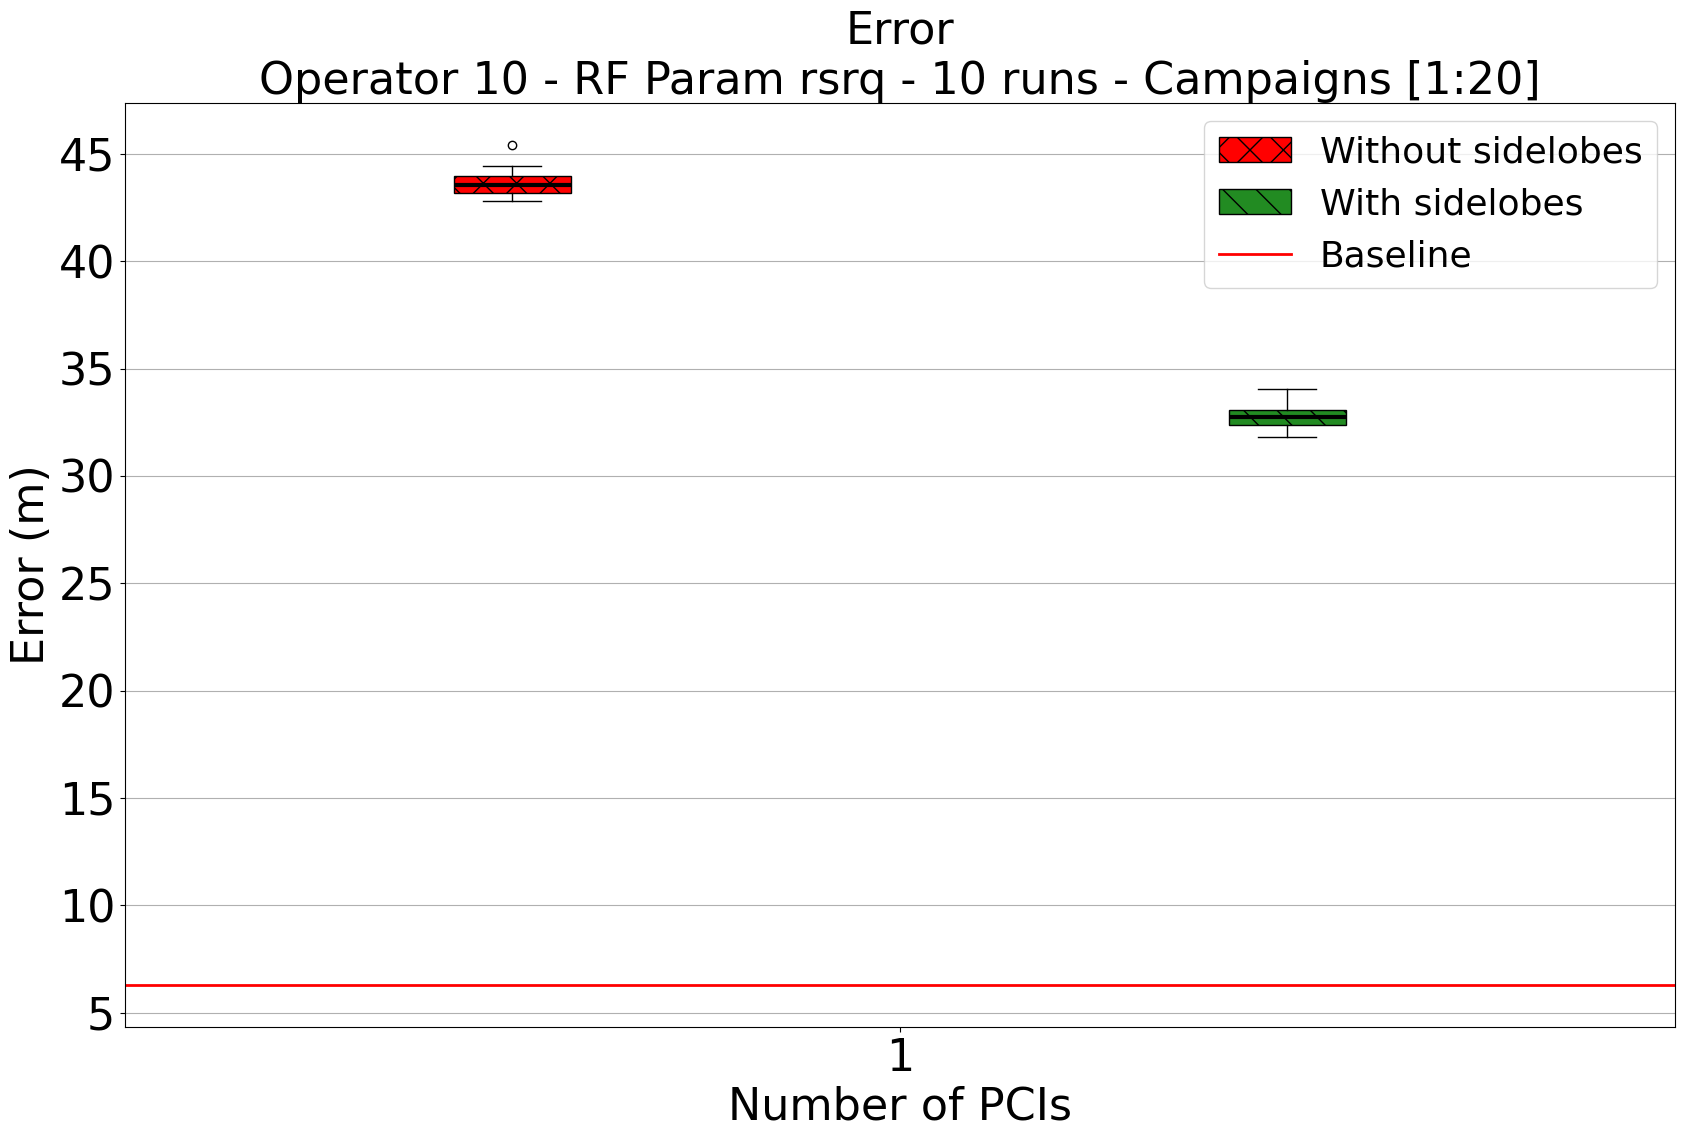

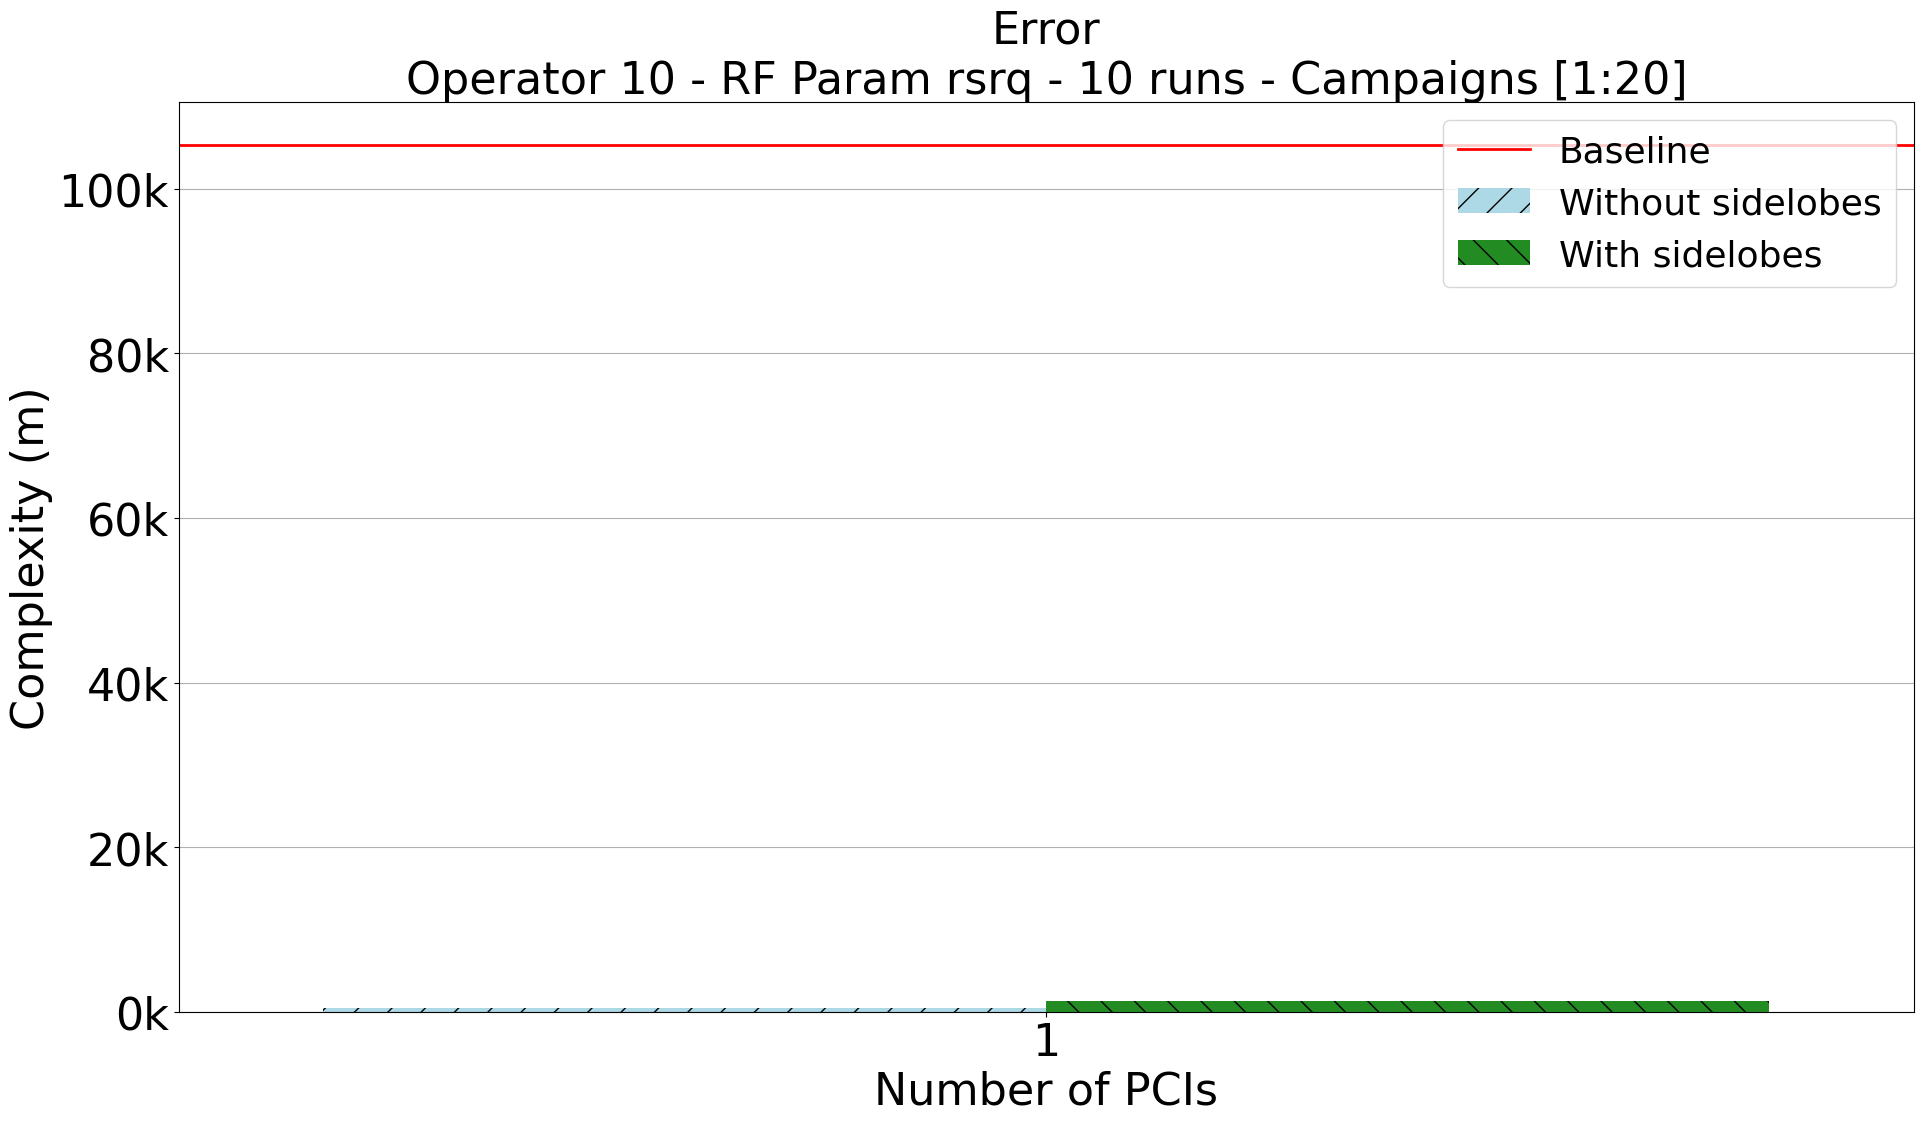

In [21]:

title = f"Operator {config['operator_choice'][0]} - RF Param {config['rf_param']} - {config['n_runs']} runs - Campaigns [{config['campaigns'][0]}:{config['campaigns'][-1]}]"

legend_labels = ["Without sidelobes", "With sidelobes"]

make_boxplot_double(
    df=errors_df_control,
    control_df=errors_df,
    x_label="Number of PCIs",
    y_label="Error (m)",
    title=f"Error\n{title}",
    legend_labels=legend_labels,
    baseline=baseline_error,
)

make_barplot_double(
    df=complexity_df_control,
    control_df=complexity_df,
    x_label="Number of PCIs",
    y_label="Complexity (m)",
    title=f"Error\n{title}",
    legend_labels=legend_labels,
    baseline=baseline_complexity,
)



In [22]:
base_df = pd.DataFrame({
    'errors': errors_df.mean(),
    'complexity': complexity_df.mean(),
    'sidelobes': False
})

with_df = pd.DataFrame({
    'errors': errors_df_control.mean(),
    'complexity': complexity_df_control.mean(),
    'sidelobes': True
})

compare_df = pd.concat([base_df, with_df], axis=0, ignore_index=True)
compare_df

,errors,complexity,sidelobes
0,43.71027,414.599751,False
1,32.75682,1243.799254,True


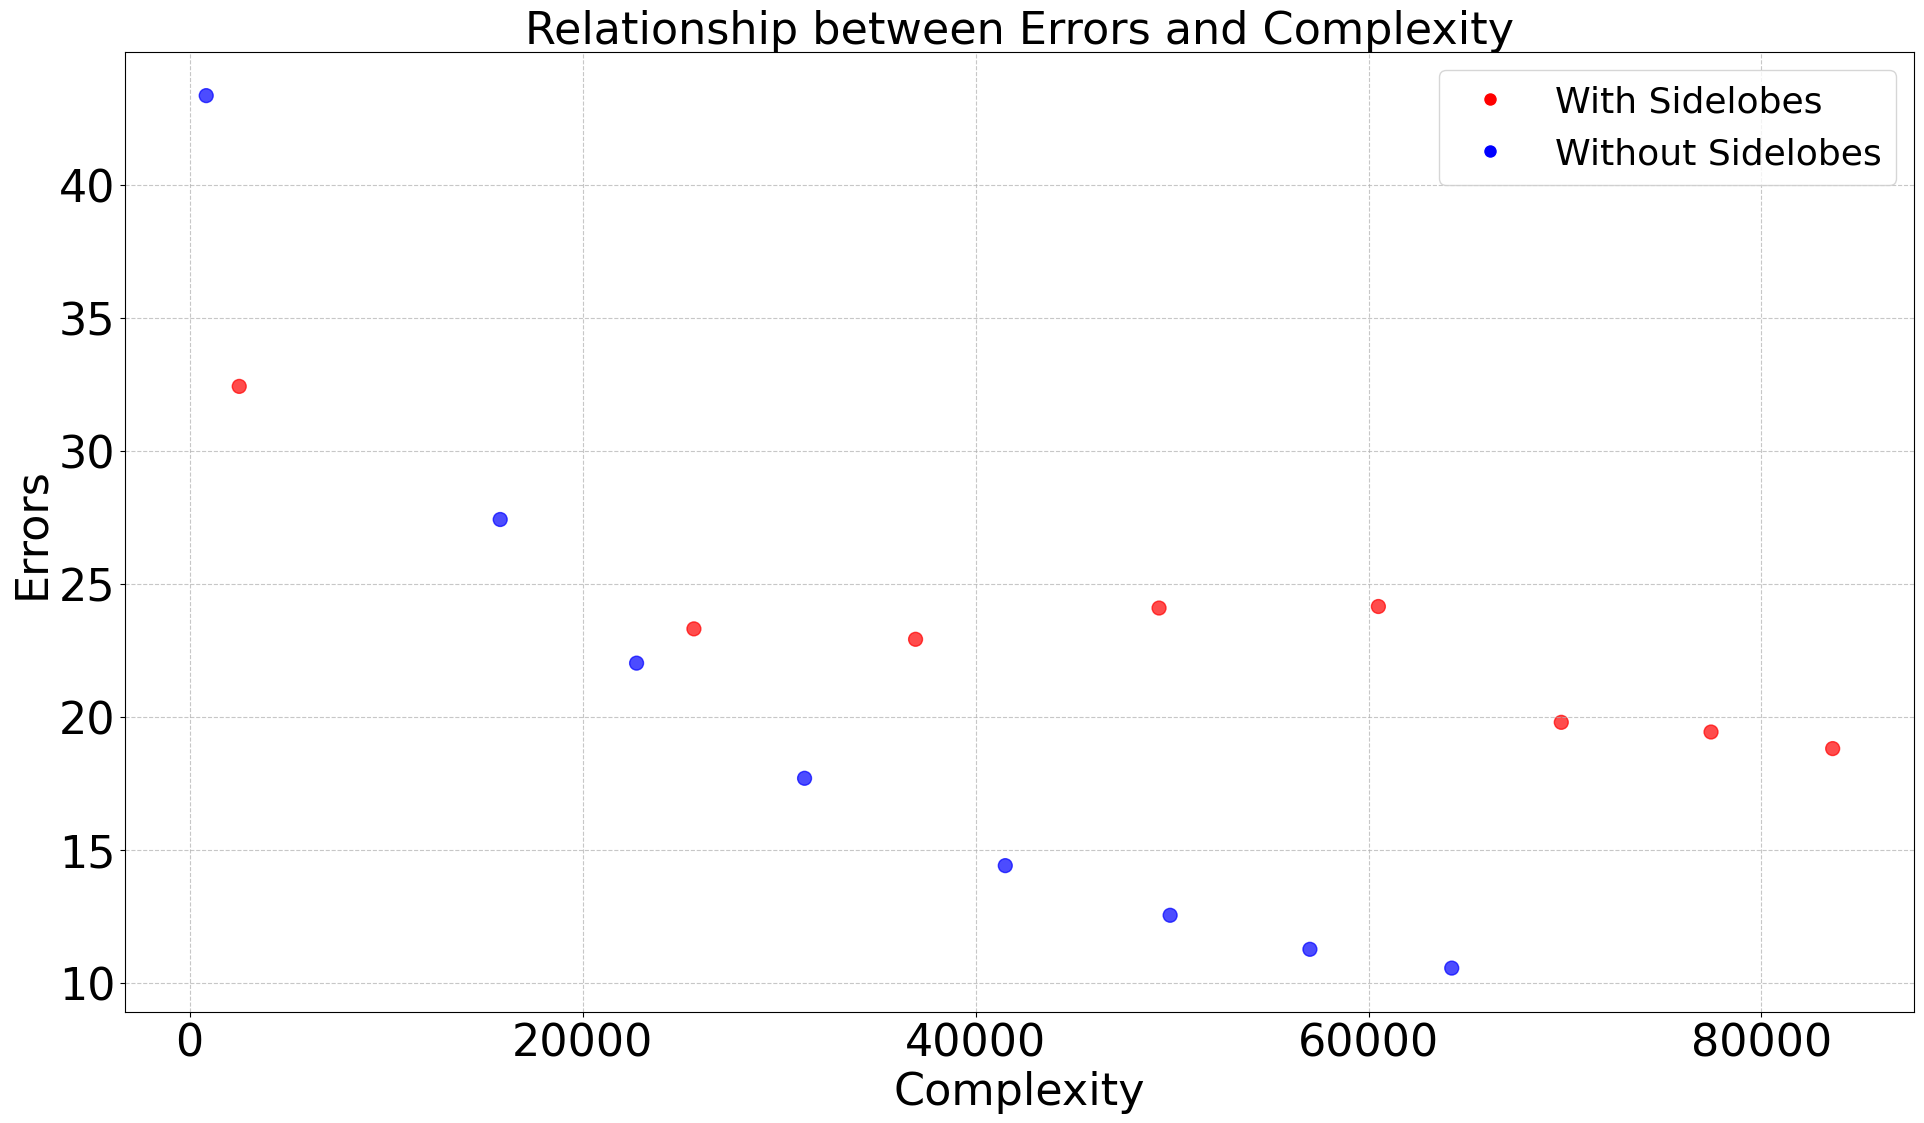

In [66]:
plt.figure(figsize=(20, 12))

# Create scatter plot with colors based on sidelobes
scatter = plt.scatter(
    compare_df['complexity'],
    compare_df['errors'],
    c=['red' if s else 'blue' for s in compare_df['sidelobes']],
    alpha=0.7,  # Adding some transparency for better visibility
    s=100  # Slightly larger point size
)

# Add axis labels with larger font size
plt.ylabel('Errors', )
plt.xlabel('Complexity', )

# Add title
plt.title('Relationship between Errors and Complexity', )

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Create proper legend
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='With Sidelobes'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Without Sidelobes')
], loc='best', )

# Adjust tick label size
plt.xticks()
plt.yticks()

plt.tight_layout()  # Adjust layout to make room for labels
plt.show()
